In [1]:
import torch
import numpy as np

In [2]:
from PIL import Image
from IPython.display import display
from __future__ import annotations

NUM_ROWS = 28
NUM_COLS = 28
NUM_LABELS = 10

class Data:
  def __init__(self, flattened_pixels: torch.Tensor, label: int):
    self.flattened_pixels = flattened_pixels
    self.label = label
  
  @classmethod
  def from_csv_row(cls, csv: list[int]) -> Data:
    label = csv[0]
    flattened_pixels = torch.tensor(csv[1:])
    flattened_pixels = flattened_pixels / 255
    return cls(flattened_pixels, label)
  
  def to_image(self) -> Image:
    numpy_array: np.ndarray = self.flattened_pixels.numpy()
    pixel_array = (numpy_array.reshape(NUM_ROWS, NUM_COLS) * 255).astype(np.uint8)
    return Image.fromarray(pixel_array, mode='L')
  
  def label_to_one_hot(self) -> torch.Tensor:
    result = torch.zeros(NUM_LABELS)
    result[self.label] = 1
    return result 

In [3]:
lines: list[str] = []
datas: list[Data] = []

with open('data/MNIST_CSV/mnist_train.csv') as f:
  lines = f.readlines()

for line in lines:
  datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [4]:
print(datas[0].label)
print(datas[0].label_to_one_hot())
display(datas[0].to_image())

5
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


In [5]:
distinct_labels = set()
for data in datas:
  distinct_labels.add(data.label)
distinct_labels

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [6]:
from torch import nn

In [7]:
device = "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.neural_network = self.initialize_neural_network()

    def initialize_neural_network(self):
        init_layer = nn.Linear(28*28, 32)
        nn.init.xavier_uniform_(init_layer.weight)
        nn.init.zeros_(init_layer.bias)

        final_layer = nn.Linear(32, 10)
        nn.init.zeros_(final_layer.bias)

        return nn.Sequential(
            init_layer,
            nn.Tanh(),
            final_layer,
        )

    def forward(self, x):
        logits = self.neural_network(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (neural_network): Sequential(
    (0): Linear(in_features=784, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [8]:
logits = model(datas[0].flattened_pixels)
predicted_probabilities = nn.Softmax(dim=0)(logits)
predicted_label = predicted_probabilities.argmax()

print(f'{predicted_label=}, {datas[0].label}')

predicted_label=tensor(0), 5


In [9]:
from datetime import datetime

In [10]:
losses: list[float] = []
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [11]:
for i, data in enumerate(datas):
  logits = model(data.flattened_pixels)
  predicted_probabilities = nn.Softmax(dim=0)(logits)
  predicted_label = predicted_probabilities.argmax()
  loss = torch.nn.functional.cross_entropy(logits, data.label_to_one_hot())
  losses.append(loss.item())
  
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if i % 100 == 0 and i > 0:
    window = losses[-100:]
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} mean_t100_loss={sum(window)/len(window):.4f}')

17:12:22 i=100 mean_t100_loss=2.1587
17:12:22 i=200 mean_t100_loss=1.8128
17:12:22 i=300 mean_t100_loss=1.5345
17:12:22 i=400 mean_t100_loss=1.2772
17:12:22 i=500 mean_t100_loss=1.1974
17:12:22 i=600 mean_t100_loss=1.1760
17:12:22 i=700 mean_t100_loss=1.1067
17:12:22 i=800 mean_t100_loss=0.8945
17:12:22 i=900 mean_t100_loss=0.8824
17:12:22 i=1000 mean_t100_loss=0.7988
17:12:22 i=1100 mean_t100_loss=0.9163
17:12:22 i=1200 mean_t100_loss=0.7308
17:12:22 i=1300 mean_t100_loss=0.7554
17:12:22 i=1400 mean_t100_loss=0.6542
17:12:23 i=1500 mean_t100_loss=0.6165
17:12:23 i=1600 mean_t100_loss=0.6185
17:12:23 i=1700 mean_t100_loss=0.4938
17:12:23 i=1800 mean_t100_loss=0.4064
17:12:23 i=1900 mean_t100_loss=0.4704
17:12:23 i=2000 mean_t100_loss=0.4960
17:12:23 i=2100 mean_t100_loss=0.5675
17:12:23 i=2200 mean_t100_loss=0.3876
17:12:23 i=2300 mean_t100_loss=0.3853
17:12:23 i=2400 mean_t100_loss=0.4313
17:12:23 i=2500 mean_t100_loss=0.4760
17:12:23 i=2600 mean_t100_loss=0.2885
17:12:23 i=2700 mean_

In [12]:
logits = model(datas[0].flattened_pixels)
predicted_probabilities = nn.Softmax(dim=0)(logits)
predicted_label = predicted_probabilities.argmax()

print(f'{predicted_label=}, {datas[0].label}')

predicted_label=tensor(5), 5


In [13]:
for name, parameter in model.named_parameters():
  print(f"Layer: {name} | Size: {parameter.size()} | Values : {parameter[:2]} \n")

Layer: neural_network.0.weight | Size: torch.Size([32, 784]) | Values : tensor([[ 0.0006,  0.0073,  0.0686,  ..., -0.0215,  0.0742, -0.0835],
        [ 0.0832,  0.0688, -0.0553,  ..., -0.0186,  0.0848,  0.0809]],
       grad_fn=<SliceBackward0>) 

Layer: neural_network.0.bias | Size: torch.Size([32]) | Values : tensor([ 0.0476, -0.2056], grad_fn=<SliceBackward0>) 

Layer: neural_network.2.weight | Size: torch.Size([10, 32]) | Values : tensor([[-1.1558,  0.2009, -0.1119,  0.5079, -0.6024,  0.0627,  0.6632,  0.4027,
          0.8313,  0.4671, -0.2708,  0.8782, -0.0101,  0.4232,  0.4399,  0.4322,
          0.4289, -0.4889, -0.3859, -0.0467, -0.4882, -0.2052,  0.9560, -0.5703,
         -0.1835, -0.5615,  0.2863,  0.4011,  0.2778,  0.1638, -0.1064,  0.4751],
        [ 0.7486, -0.1722, -0.1762,  0.3793, -0.5690,  0.6724,  0.7184, -0.9087,
         -0.5932, -0.2666,  0.7322, -0.3120,  0.5252, -0.4757, -1.0808, -0.0269,
         -0.6298,  0.5353,  0.5506,  0.2234,  0.1825, -0.1805,  0.1879, -0

In [14]:
import matplotlib.pyplot as plt

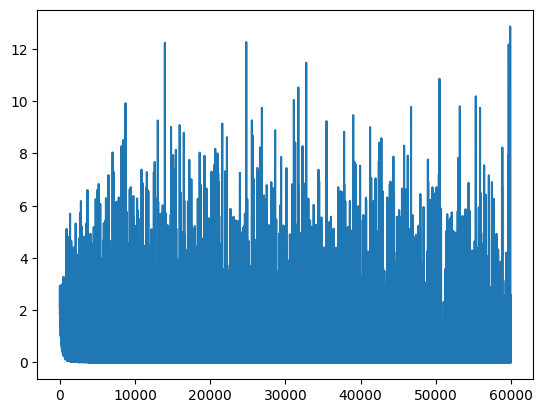

In [15]:
# noisy
plt.plot(losses)

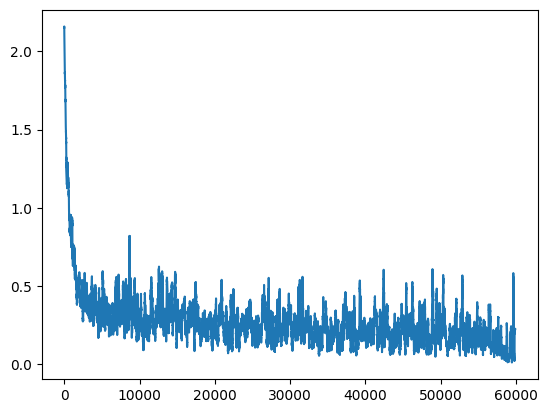

In [16]:
# smooth
mean_t100_losses: list[float] = []
for i in range(100, len(losses)):
  mean_t100_losses.append(sum(losses[i-100:i]) / 100)

plt.plot(mean_t100_losses)

## Save model

In [17]:
torch.save(model.state_dict(), "data/MNIST_CSV/model.pth")

## Load saved model

In [18]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("data/MNIST_CSV/model.pth", weights_only=True))

<All keys matched successfully>

## Test

In [19]:
lines: list[str] = []
datas_test: list[Data] = []

with open('data/MNIST_CSV/mnist_test.csv') as f:
  lines = f.readlines()

for line in lines:
  datas_test.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [20]:
# switch to inference mode: eval() for dropout/batchnorm behaviour,
# and wrap predictions below in `with torch.no_grad():` to skip autograd
model.eval()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (neural_network): Sequential(
    (0): Linear(in_features=784, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [21]:
datas_test[0].label

7

In [22]:
with torch.no_grad():
  logits = model(datas_test[0].flattened_pixels)
predicted_probabilities = nn.Softmax(dim=0)(logits)
for label, probability in enumerate(predicted_probabilities):
  print(f'P({label}) = {probability.item()}')
predicted_label = predicted_probabilities.argmax()

print(f'{predicted_label=}, {datas_test[0].label}')

P(0) = 2.1062869564048015e-05
P(1) = 2.1442887998546212e-07
P(2) = 4.07107436330989e-05
P(3) = 0.0006216290639713407
P(4) = 7.354615263466258e-07
P(5) = 3.1074487196747214e-06
P(6) = 1.447381769992262e-08
P(7) = 0.9992467164993286
P(8) = 5.322932338458486e-06
P(9) = 6.04549131821841e-05
predicted_label=tensor(7), 7


In [23]:
class TestOutcome:
  def __init__(
      self,
      test_case_index: int,
      correct_label: int,
      predicted_label: int,
      predicted_label_to_probability: dict[int, float],
  ):
    test_case_index = test_case_index
    self.correct_label = correct_label
    self.predicted_label = predicted_label
    self.predicted_label_to_probability = predicted_label_to_probability

  def __repr__(self) -> str:
    return f'{self.__class__.__name__}({self.__dict__})'

In [24]:
test_outcomes: list[TestOutcome] = []
incorrect_test_outcomes: list[TestOutcome] = []

In [25]:
from datetime import datetime

In [26]:
for i in range(len(datas_test)):
  # compute prediction
  data = datas_test[i]
  with torch.no_grad():
    logits = model(data.flattened_pixels)
  predicted_probabilities = nn.Softmax(dim=0)(logits)

  predicted_label_to_probability: dict[int, float] = {}
  for label, probability in enumerate(predicted_probabilities):
    predicted_label_to_probability[label] = probability.item()
  predicted_label = predicted_probabilities.argmax()

  predicted_label = max(predicted_label_to_probability.keys(), key=lambda label: predicted_label_to_probability[label])
  
  test_outcome = TestOutcome(
      test_case_index=i,
      correct_label=data.label,
      predicted_label=predicted_label,
      predicted_label_to_probability=predicted_label_to_probability,
  )
  
  # update state
  test_outcomes.append(test_outcome)
  if test_outcome.correct_label != test_outcome.predicted_label:
    incorrect_test_outcomes.append(test_outcome)

  if i % 100 == 0 and i > 0:
    print(f'{datetime.now().strftime("%H:%M:%S")} {i=} current_score={(i - len(incorrect_test_outcomes)) / i:.4f}')

17:12:53 i=100 current_score=0.9500
17:12:53 i=200 current_score=0.9700
17:12:53 i=300 current_score=0.9500
17:12:53 i=400 current_score=0.9500
17:12:53 i=500 current_score=0.9500
17:12:53 i=600 current_score=0.9433
17:12:53 i=700 current_score=0.9429
17:12:53 i=800 current_score=0.9413
17:12:53 i=900 current_score=0.9411
17:12:53 i=1000 current_score=0.9400
17:12:53 i=1100 current_score=0.9391
17:12:53 i=1200 current_score=0.9383
17:12:53 i=1300 current_score=0.9331
17:12:53 i=1400 current_score=0.9336
17:12:53 i=1500 current_score=0.9340
17:12:53 i=1600 current_score=0.9337
17:12:53 i=1700 current_score=0.9329
17:12:53 i=1800 current_score=0.9300
17:12:53 i=1900 current_score=0.9284
17:12:53 i=2000 current_score=0.9265
17:12:53 i=2100 current_score=0.9252
17:12:53 i=2200 current_score=0.9232
17:12:53 i=2300 current_score=0.9239
17:12:53 i=2400 current_score=0.9246
17:12:53 i=2500 current_score=0.9244
17:12:53 i=2600 current_score=0.9254
17:12:53 i=2700 current_score=0.9259
17:12:53 i